school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
class         0
dtype: int64


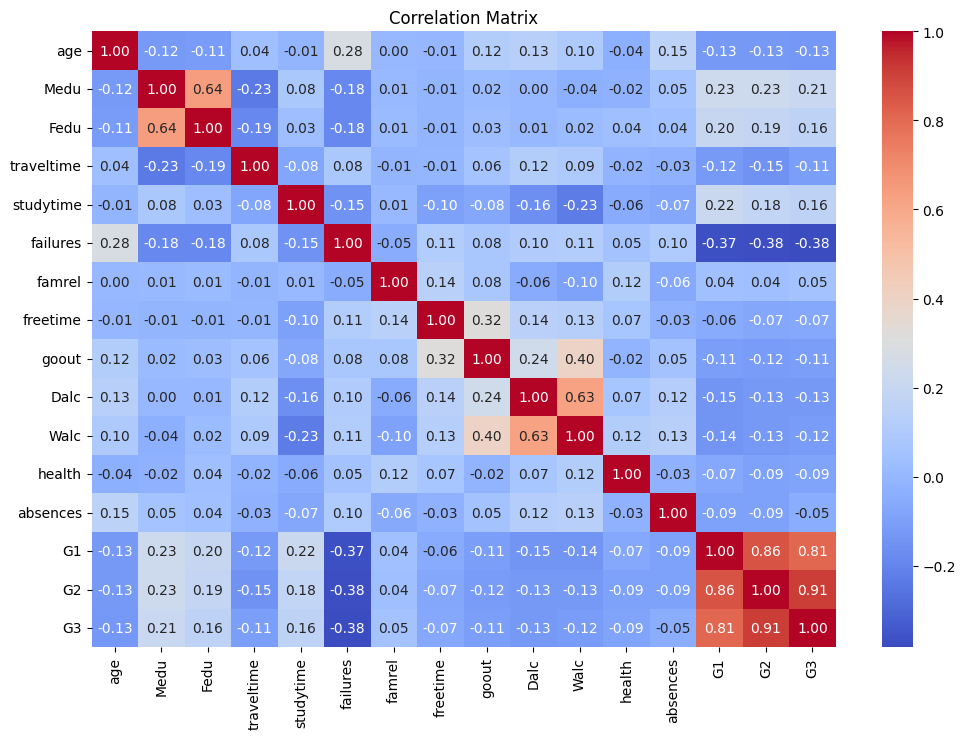

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据，确保正确的分隔符
df_combined = pd.read_csv("data/student_combined_cleaned.csv", sep=",", encoding="utf-8")

# 手动选择数值列（只选择实际为数值的列）
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

# 确保这些列为数值型数据
df_combined[numeric_cols] = df_combined[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 对分类列使用类别数据类型
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
df_combined[categorical_cols] = df_combined[categorical_cols].astype('category')

# 填充数值列的缺失值（使用中位数填充）
df_combined[numeric_cols] = df_combined[numeric_cols].fillna(df_combined[numeric_cols].median())

# 填充分类列的缺失值（使用最常见的类别填充）
df_combined[categorical_cols] = df_combined[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

# 检查是否还有缺失值
print(df_combined.isnull().sum())

# 计算数值列的相关性矩阵
correlation_matrix = df_combined[numeric_cols].corr()

# 绘制相关性热力图
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


选中的数值列:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3'],
      dtype='object')


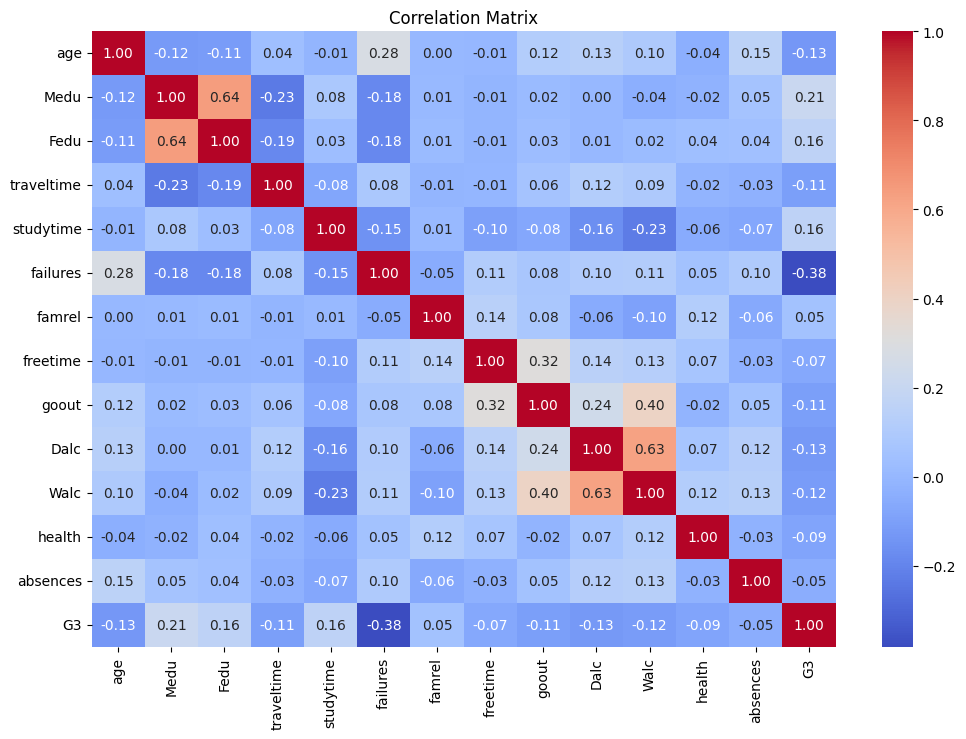

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 读取数据，确保正确的分隔符
df_combined = pd.read_csv("data/student_combined_cleaned.csv", sep=",", encoding="utf-8")

# 手动选择数值列（只选择实际为数值的列）
numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 
                'absences', 'G1', 'G2', 'G3']

# 确保这些列为数值型
df_combined[numeric_cols] = df_combined[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 对分类列使用类别数据类型
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 
                    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 
                    'nursery', 'higher', 'internet', 'romantic']
df_combined[categorical_cols] = df_combined[categorical_cols].astype('category')

# 填充数值列的缺失值（使用中位数填充）
df_combined[numeric_cols] = df_combined[numeric_cols].fillna(df_combined[numeric_cols].median())

# 填充分类列的缺失值（使用最常见的类别填充）
df_combined[categorical_cols] = df_combined[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

# 标准化数值列
scaler = StandardScaler()
df_combined[numeric_cols] = scaler.fit_transform(df_combined[numeric_cols])

# 删除 G1 和 G2，只保留 G3 作为目标变量
df_combined = df_combined.drop(columns=['G1', 'G2'])

# **🔹 关键修改：只选择数值列**
numeric_df = df_combined.select_dtypes(include=['number'])
print("\n选中的数值列:")
print(numeric_df.columns)

# 计算数值列的相关性矩阵
correlation_matrix = numeric_df.corr()

# **🔹 相关性热力图**
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

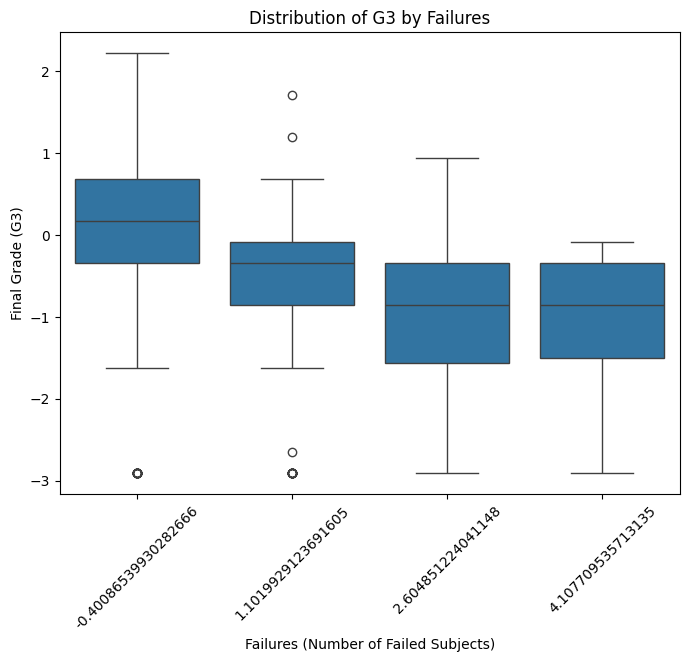

In [15]:
# 绘制 failures 和 G3 之间的箱线图
plt.figure(figsize=(8,6))
sns.boxplot(x='failures', y='G3', data=df_combined)
plt.title('Distribution of G3 by Failures')
plt.xlabel("Failures (Number of Failed Subjects)")
plt.ylabel("Final Grade (G3)")
plt.xticks(rotation=45)  # 旋转横坐标标签
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_6212\3919906774.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='studytime', y='G3', data=df_combined, jitter=True, palette="Set2")


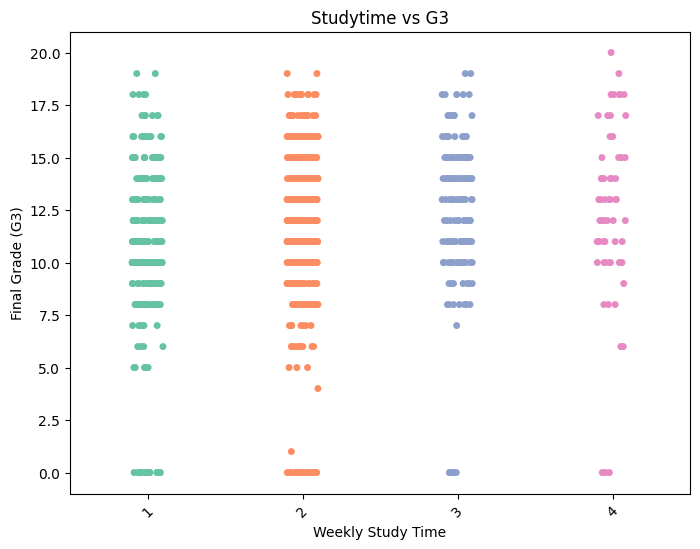

C:\Users\admin\AppData\Local\Temp\ipykernel_6212\3919906774.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='studytime', y='G3', data=df_combined, palette="Set2")


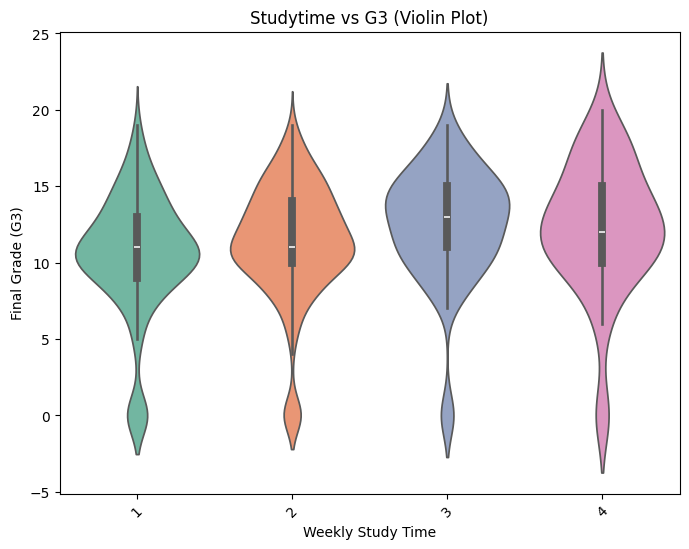

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df_combined = pd.read_csv("data/student_combined_cleaned.csv", sep=",", encoding="utf-8")

# 使用 stripplot 展示 studytime 和 G3 之间的关系
plt.figure(figsize=(8,6))
sns.stripplot(x='studytime', y='G3', data=df_combined, jitter=True, palette="Set2")
plt.title('Studytime vs G3')
plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")
plt.xticks(rotation=45)  # 旋转横坐标标签以避免重叠
plt.show()

# 使用 violinplot 展示 studytime 和 G3 之间的关系
plt.figure(figsize=(8,6))
sns.violinplot(x='studytime', y='G3', data=df_combined, palette="Set2")
plt.title('Studytime vs G3 (Violin Plot)')
plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")
plt.xticks(rotation=45)  # 旋转横坐标标签以避免重叠
plt.show()

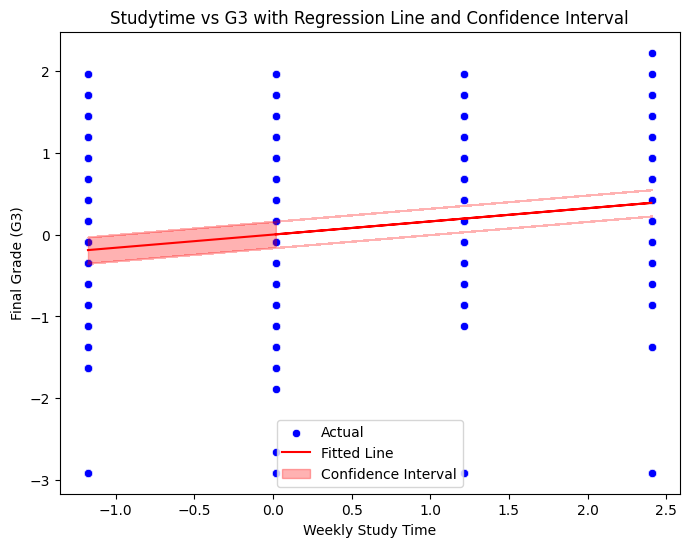

In [17]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 对 studytime 和 G3 进行回归分析
X = df_combined[['studytime']].dropna()  # 选择 studytime 并去除缺失值
y = df_combined.loc[X.index, 'G3']  # 选择相应的 G3 数据

# 创建并拟合模型
model = LinearRegression()
model.fit(X, y)

# 生成预测值
y_pred = model.predict(X)

# 绘制回归线及其误差带
plt.figure(figsize=(8,6))
sns.scatterplot(x=X['studytime'], y=y, color='blue', label='Actual')
plt.plot(X['studytime'], y_pred, color='red', label='Fitted Line')
plt.fill_between(X['studytime'], y_pred - np.std(y_pred), y_pred + np.std(y_pred), color='red', alpha=0.3, label='Confidence Interval')
plt.title('Studytime vs G3 with Regression Line and Confidence Interval')
plt.xlabel("Weekly Study Time")
plt.ylabel("Final Grade (G3)")
plt.legend()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_6212\1024512024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Medu', y='G3', data=df_combined, palette="Set2")


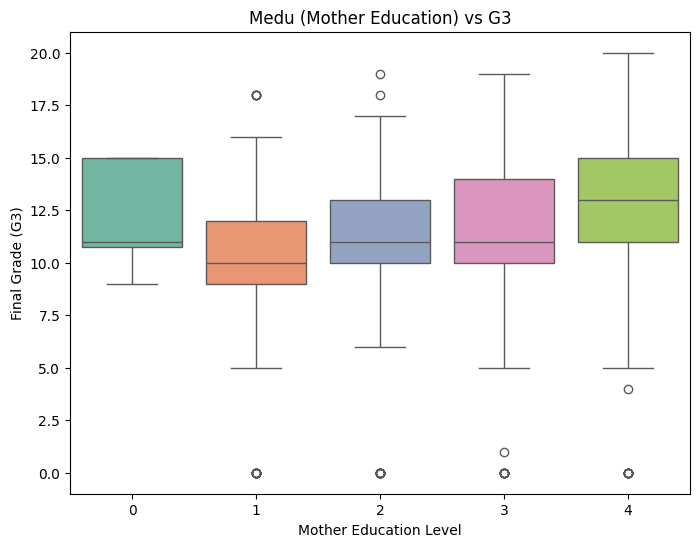

In [7]:
# 使用 boxplot 展示 Medu 和 G3 之间的关系
plt.figure(figsize=(8,6))
sns.boxplot(x='Medu', y='G3', data=df_combined, palette="Set2")
plt.title('Medu (Mother Education) vs G3')
plt.xlabel("Mother Education Level")
plt.ylabel("Final Grade (G3)")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_6212\2838554804.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Medu', y='G3', data=df_combined, jitter=True, palette="Set2")


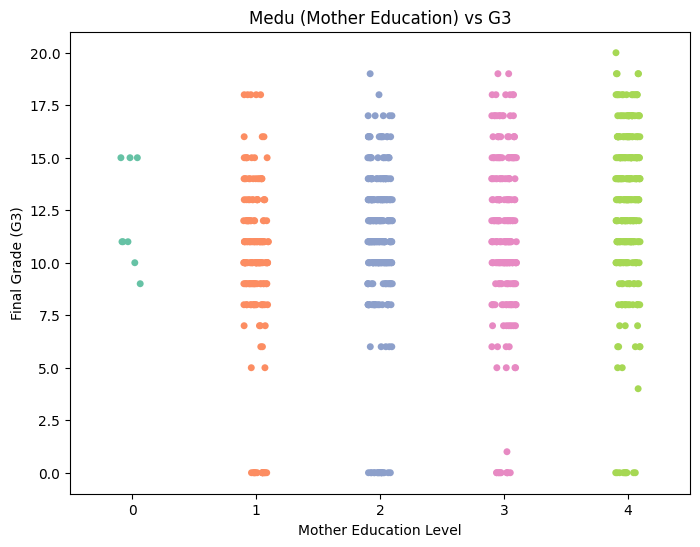

In [12]:
# 使用 scatterplot 展示 Medu 和 G3 之间的关系（带抖动）
plt.figure(figsize=(8,6))
sns.stripplot(x='Medu', y='G3', data=df_combined, jitter=True, palette="Set2")
plt.title('Medu (Mother Education) vs G3')
plt.xlabel("Mother Education Level")
plt.ylabel("Final Grade (G3)")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_6212\1289602992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fedu', y='G3', data=df_combined, palette="Set2")


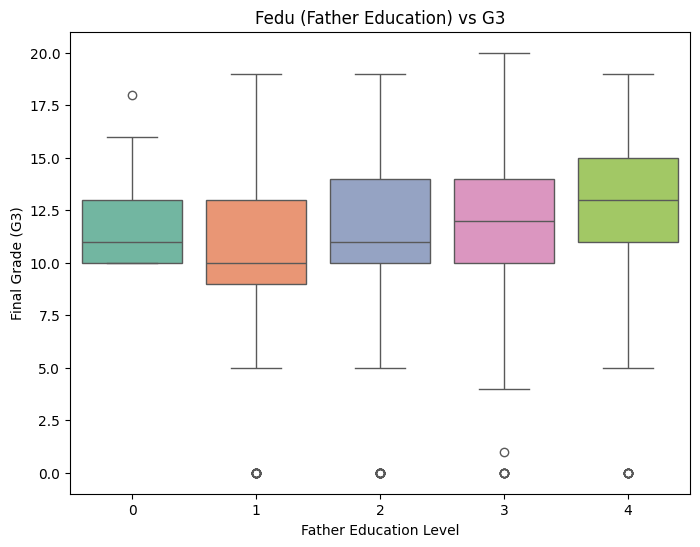

In [8]:
# 使用 boxplot 展示 Fedu 和 G3 之间的关系
plt.figure(figsize=(8,6))
sns.boxplot(x='Fedu', y='G3', data=df_combined, palette="Set2")
plt.title('Fedu (Father Education) vs G3')
plt.xlabel("Father Education Level")
plt.ylabel("Final Grade (G3)")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_6212\104030600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Fedu', y='G3', data=df_combined, jitter=True, palette="Set2")


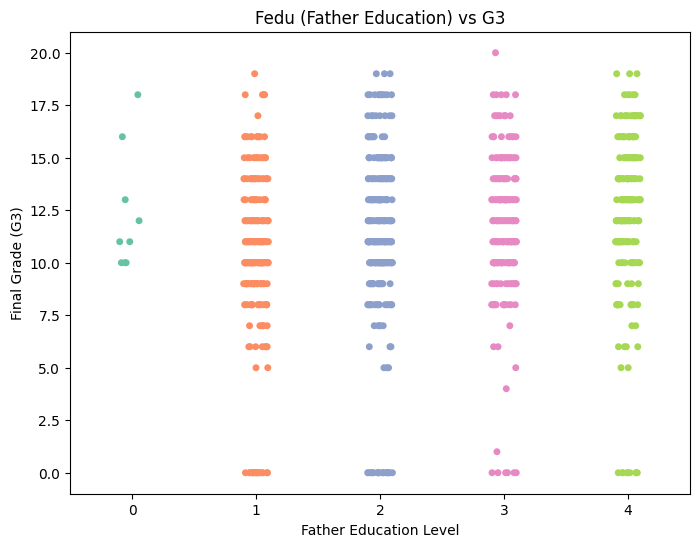

In [13]:
# 使用 scatterplot 展示 Fedu 和 G3 之间的关系（带抖动）
plt.figure(figsize=(8,6))
sns.stripplot(x='Fedu', y='G3', data=df_combined, jitter=True, palette="Set2")
plt.title('Fedu (Father Education) vs G3')
plt.xlabel("Father Education Level")
plt.ylabel("Final Grade (G3)")
plt.show()

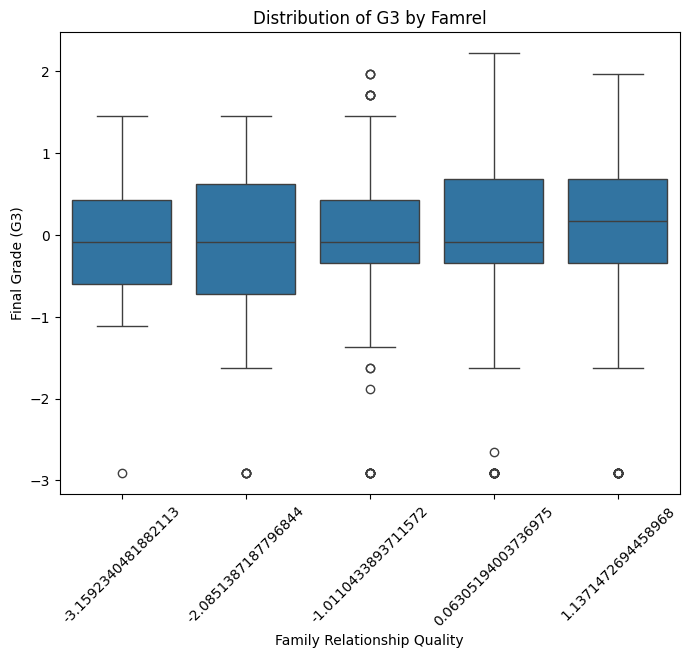

In [14]:
# 绘制 famrel 和 G3 之间的箱线图
plt.figure(figsize=(8,6))
sns.boxplot(x='famrel', y='G3', data=df_combined)
plt.title('Distribution of G3 by Famrel')
plt.xlabel("Family Relationship Quality")
plt.ylabel("Final Grade (G3)")
plt.xticks(rotation=45)  # 旋转横坐标标签
plt.show()

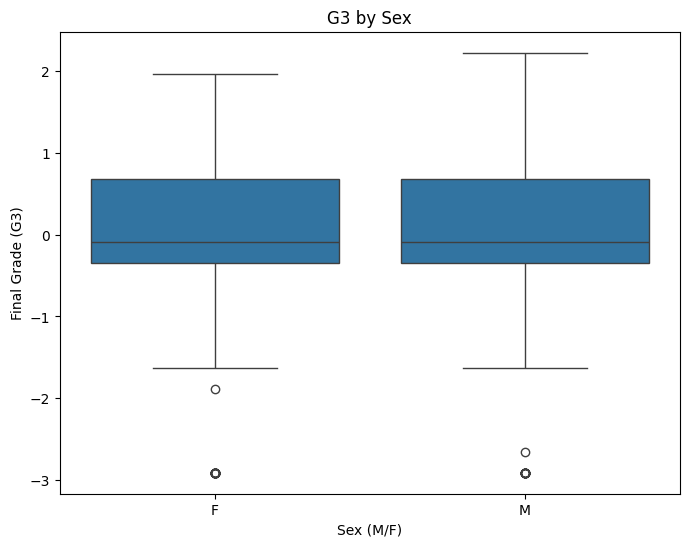

In [11]:
## 4. `sex` 和 `G3` 之间的箱线图
plt.figure(figsize=(8,6))
sns.boxplot(x='sex', y='G3', data=df_combined)
plt.title('G3 by Sex')
plt.xlabel("Sex (M/F)")
plt.ylabel("Final Grade (G3)")
plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df_combined = pd.read_csv("data/student_combined_cleaned.csv", sep=",", encoding="utf-8")

# 确保分类变量是类别数据类型
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 
                    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 
                    'nursery', 'higher', 'internet', 'romantic']
df_combined[categorical_cols] = df_combined[categorical_cols].astype('category')

# 定义一个函数绘制条形图
def plot_categorical_barplot(column_name):
    plt.figure(figsize=(8,6))
    sns.barplot(x=column_name, y='G3', data=df_combined, estimator=lambda x: sum(x)/len(x), ci=None, palette="Set2")
    plt.title(f'Average G3 Score by {column_name}')
    plt.xlabel(column_name)
    plt.ylabel("Average Final Grade (G3)")
    plt.xticks(rotation=45)  # 旋转横坐标，使标签更清晰
    plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


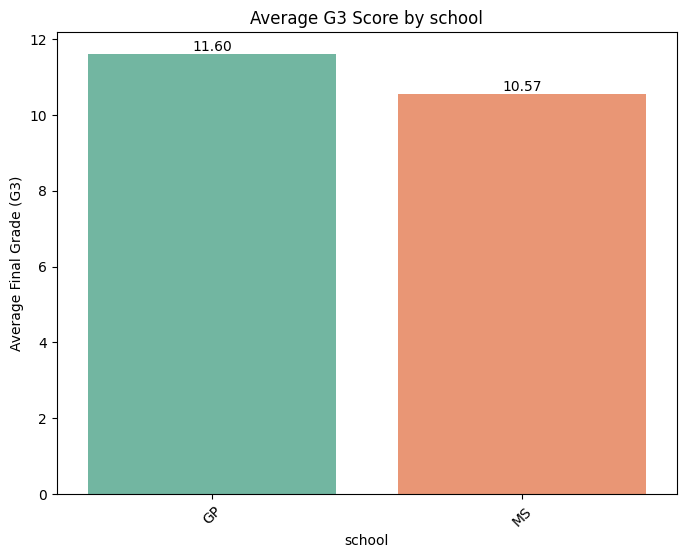

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


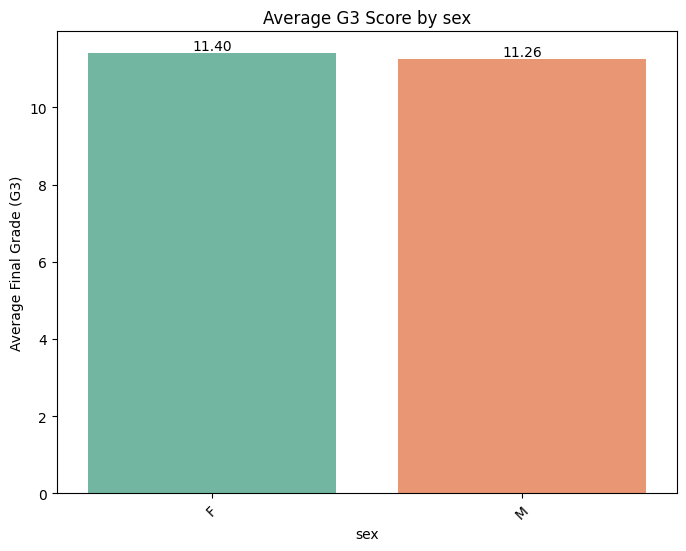

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


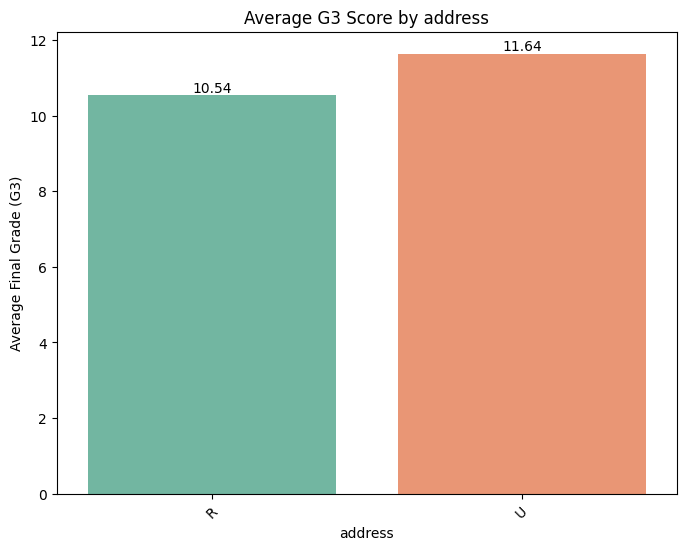

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


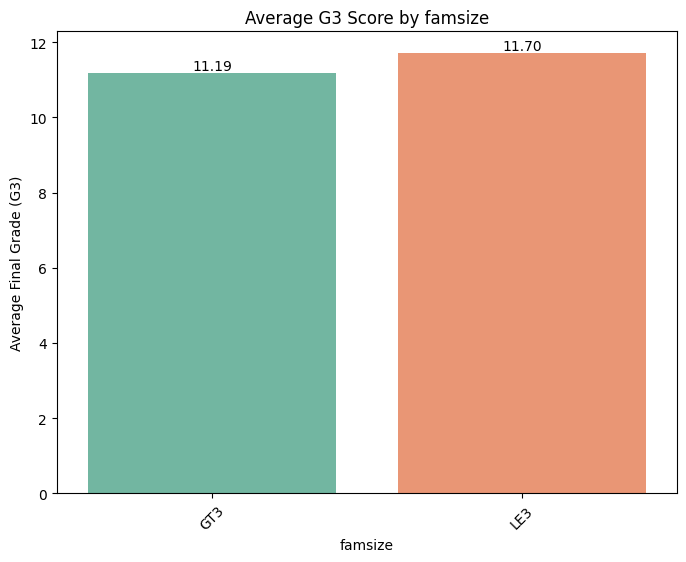

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


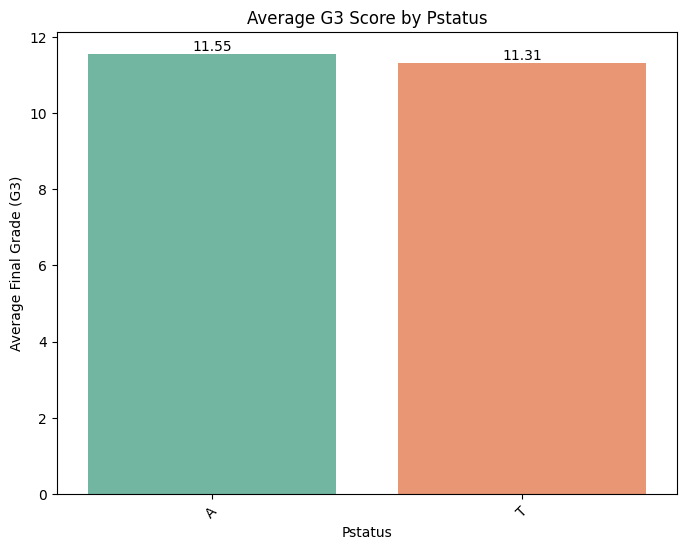

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


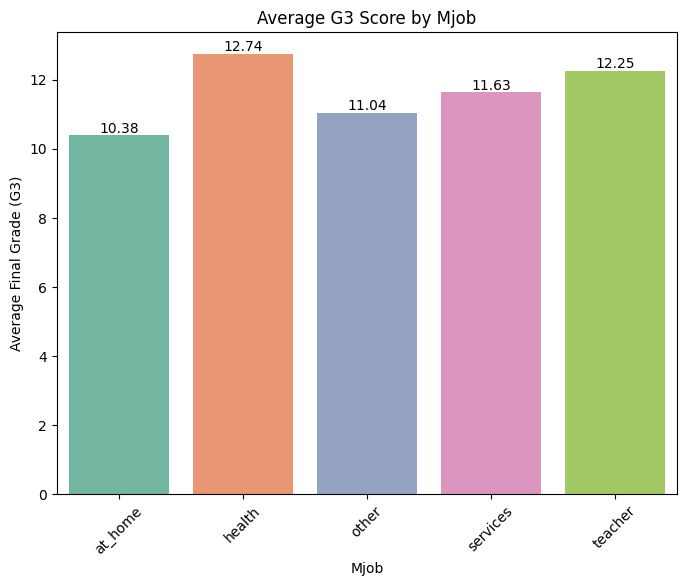

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


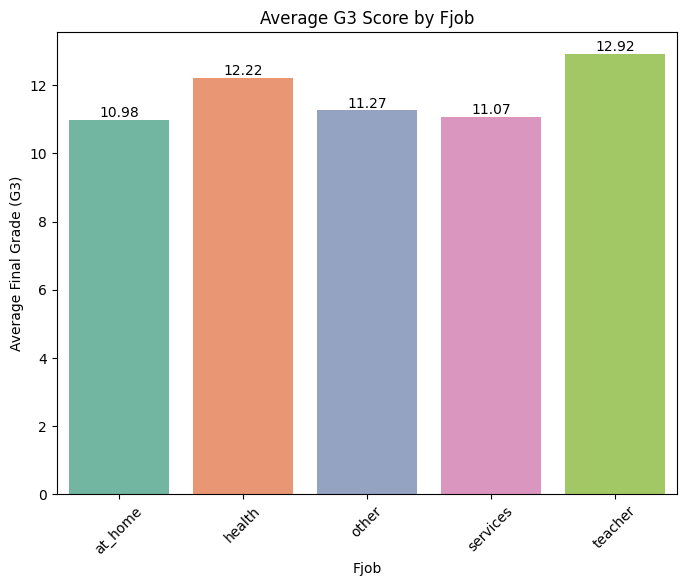

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


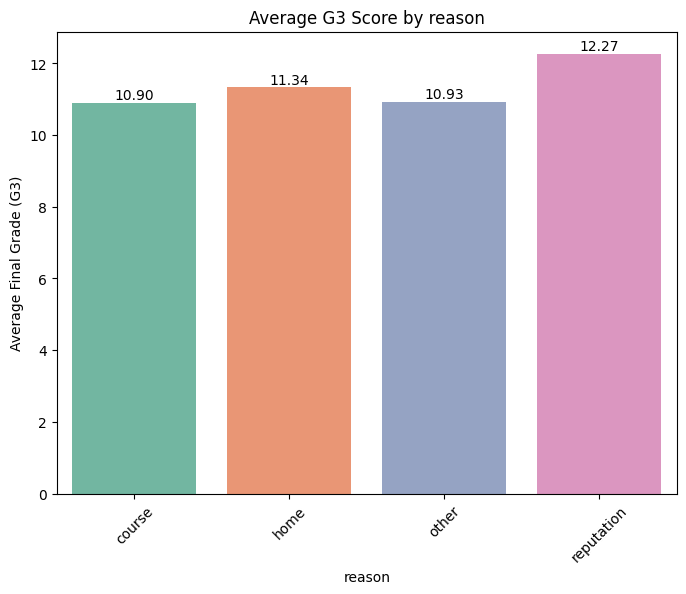

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


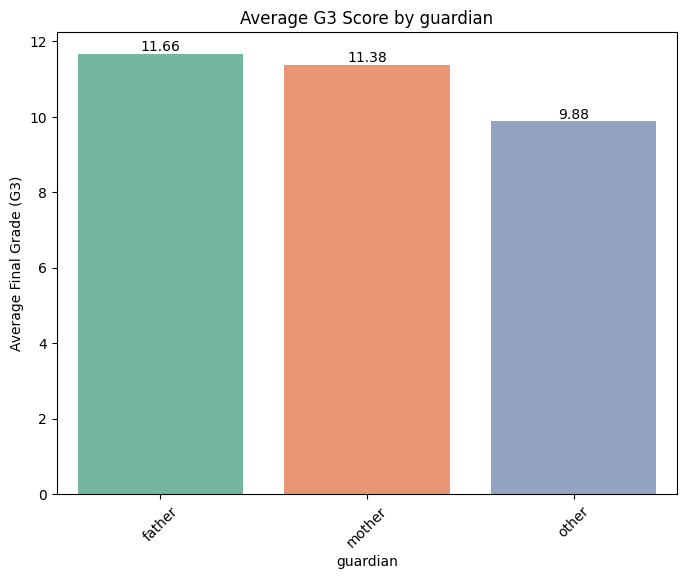

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


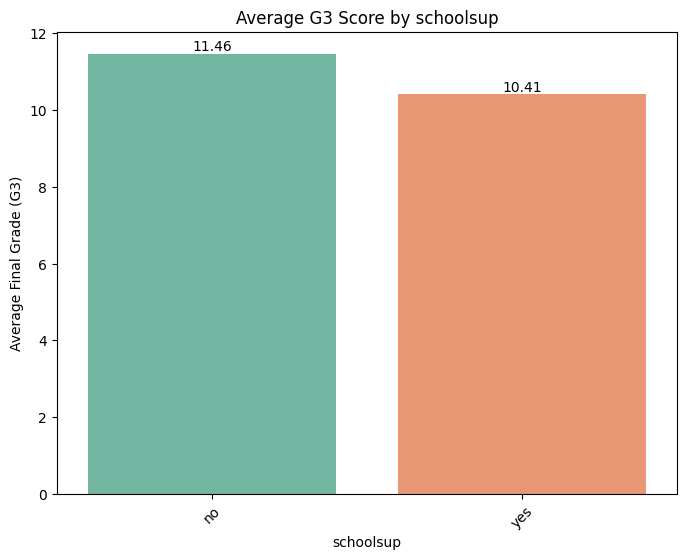

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


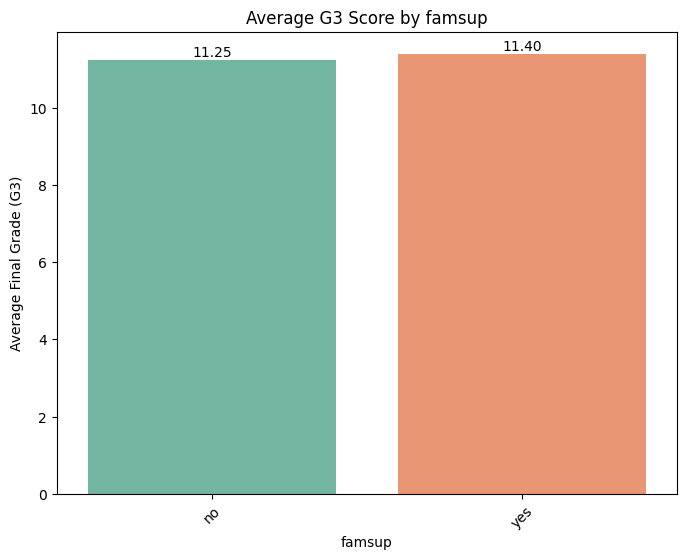

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


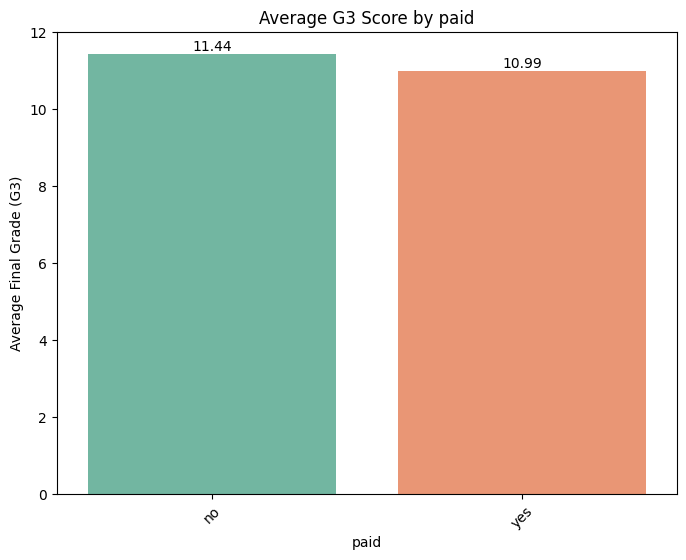

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


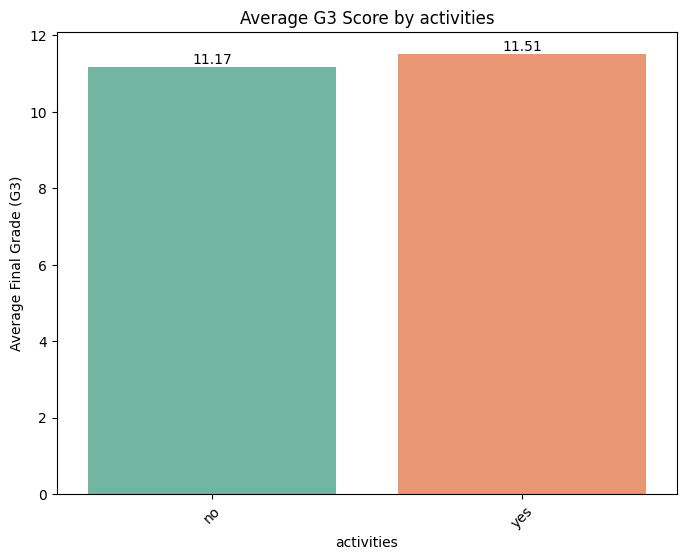

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


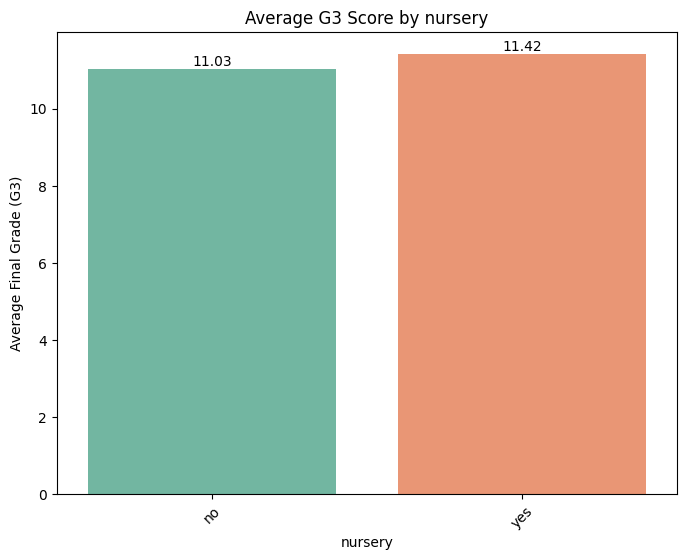

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


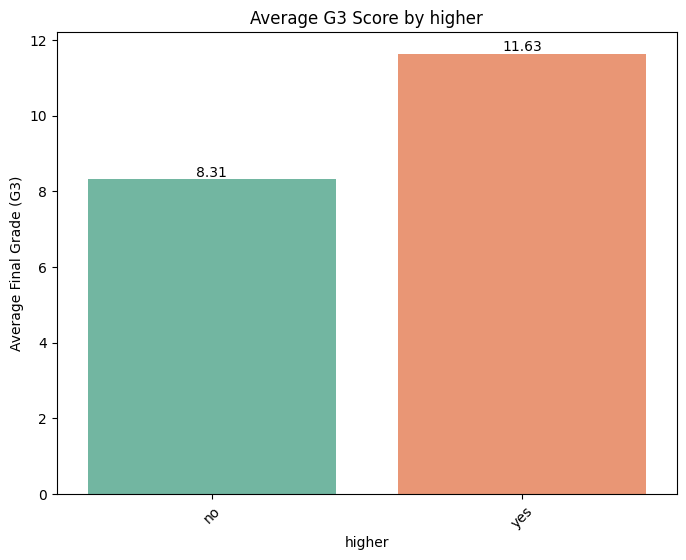

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


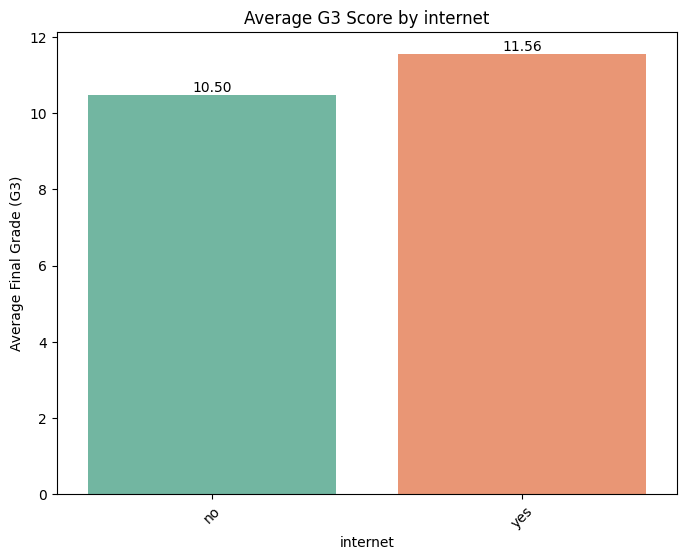

C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
C:\Users\admin\AppData\Local\Temp\ipykernel_22196\2994550144.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")


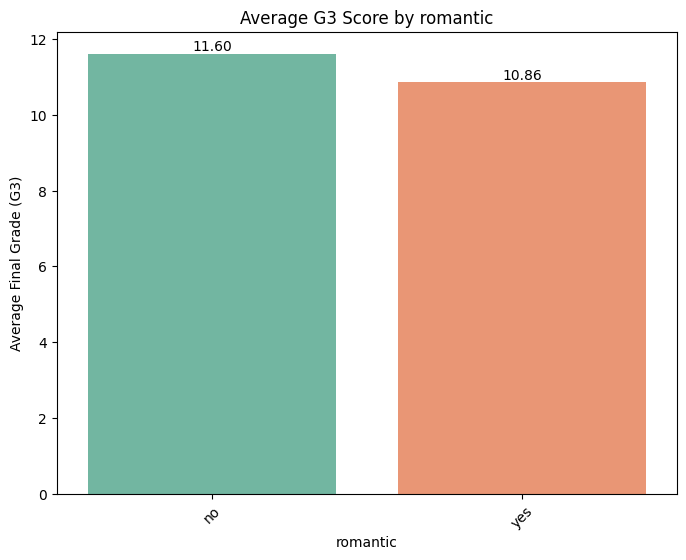

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df_combined = pd.read_csv("data/student_combined_cleaned.csv", sep=",", encoding="utf-8")

# 确保分类变量是类别数据类型
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 
                    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 
                    'nursery', 'higher', 'internet', 'romantic']
df_combined[categorical_cols] = df_combined[categorical_cols].astype('category')

# 遍历每个分类变量并绘制条形图
for col in categorical_cols:
    plt.figure(figsize=(8,6))
    ax = sns.barplot(x=col, y='G3', data=df_combined, ci=None, palette="Set2")
    plt.title(f'Average G3 Score by {col}')
    plt.xlabel(col)
    plt.ylabel("Average Final Grade (G3)")
    plt.xticks(rotation=45)  # 旋转横坐标，防止重叠
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')  # 显示每个条形的数值
    plt.show()